# H2 · H3: Mevsimsellik Anomalisi — Ocak Etkisi & Aylık Getirilerde ANOVA
## S&P 500 — Kantitatif Araştırma Serisi

**Yazar:** Furkan Çelik  
**Veri:** Özel PostgreSQL pipeline · yfinance API · ~500 hisse · 2008–Günümüz  
**Araçlar:** Python, PostgreSQL, SQLAlchemy, SciPy, Seaborn

---

### 1. Hipotez Tanımı

| | H2 — Ocak / Aralık Etkisi | H3 — Mevsimsellik (ANOVA) |
|---|---|---|
| **Araştırma Sorusu** | Ocak ve Aralık ayları yılın diğer aylarından tutarlı bir şekilde daha iyi performans gösteriyor mu? | 12 takvim ayının getirileri arasında istatistiksel olarak anlamlı bir fark var mı? |
| **H₀ (Sıfır Hipotezi)** | Ocak & Aralık getirileri = Diğer aylar getirileri | Tüm 12 ayın ortalama getirisi eşittir |
| **H₁ (Alternatif Hipotez)** | Ocak & Aralık getirileri > Diğer aylar getirileri | En az bir ayın ortalama getirisi anlamlı ölçüde farklıdır |

### 2. Veri & Metodoloji

| | |
|---|---|
| **Evren (Population)** | S&P 500 bileşenleri · 2008–Günümüz (Modern dönem) |
| **Değişkenler** | Her takvim ayı için hisse başına aylık yüzdesel getiri |
| **H2 Testi** | Welch'in Bağımsız İki Örneklem T-Testi (tek kuyruklu, alternative='greater') |
| **H3 Testi** | 12 bağımsız ay grubu üzerinde Tek Yönlü ANOVA (F-testi) |
| **Anlamlılık Düzeyi** | α = 0.05 |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from IPython.display import display, Markdown
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append('..')
from db_utils import fetch_data

sns.set_theme(style="darkgrid")
plt.rcParams.update({'figure.figsize': (13, 6), 'figure.dpi': 120})

MONTH_NAMES = {1:'Oca', 2:'Şub', 3:'Mar', 4:'Nis', 5:'May', 6:'Haz',
               7:'Tem', 8:'Ağu', 9:'Eyl', 10:'Eki', 11:'Kas', 12:'Ara'}

print("✅ Ortam hazır.")


✅ Ortam hazır.


### 3. Veri Çekme

In [2]:
# SQL: 2008'den beri her hisse için her ayın getirisini hesapla
query = """
WITH MonthlyPrices AS (
    SELECT
        ticker,
        EXTRACT(YEAR  FROM date) AS year,
        EXTRACT(MONTH FROM date) AS month,
        close,
        ROW_NUMBER() OVER(PARTITION BY ticker, EXTRACT(YEAR FROM date), EXTRACT(MONTH FROM date) ORDER BY date ASC)  AS first_day,
        ROW_NUMBER() OVER(PARTITION BY ticker, EXTRACT(YEAR FROM date), EXTRACT(MONTH FROM date) ORDER BY date DESC) AS last_day
    FROM daily_prices
    WHERE date >= '2008-01-01'
),
MonthStart AS (SELECT ticker, year, month, close AS start_price FROM MonthlyPrices WHERE first_day = 1),
MonthEnd   AS (SELECT ticker, year, month, close AS end_price   FROM MonthlyPrices WHERE last_day  = 1)
SELECT
    ms.year, ms.month, ms.ticker,
    ((me.end_price - ms.start_price) / ms.start_price) * 100 AS return_pct
FROM MonthStart ms
JOIN MonthEnd me ON ms.ticker = me.ticker AND ms.year = me.year AND ms.month = me.month
"""

print("Ham aylık getiriler çekiliyor (birkaç saniye sürebilir)...")
df = fetch_data(query)
df['month_name'] = df['month'].map(MONTH_NAMES)
print(f"Veriseti: {len(df):,} aylık getiri gözlemi yüklendi.")
display(df.head())


Ham aylık getiriler çekiliyor (birkaç saniye sürebilir)...


Veriseti: 103,373 aylık getiri gözlemi yüklendi.


,year,month,ticker,return_pct,month_name
0,2008.0,1.0,A,-6.721772,Oca
1,2008.0,2.0,A,-11.172367,Şub
2,2008.0,3.0,A,-2.960309,Mar
3,2008.0,4.0,A,-2.201324,Nis
4,2008.0,5.0,A,20.225030,May


### 4a. H2 — Welch T-Testi: Ocak & Aralık vs Diğerleri


#### H2 İstatistiksel Bulgular

| Metrik | Değer |
|---|---|
| **Ocak & Aralık — N / Ort. Getiri** | 17,308 gözlem · **%1.312** |
| **Diğer Aylar — N / Ort. Getiri** | 86,065 gözlem · **%1.295** |
| **T-İstatistiği** | 0.2176 |
| **p-değeri (tek kuyruklu)** | 4.1385e-01 |
| **H₀ Kararı** | Reddedilmedi (p ≥ 0.05) |

#### Ticari Karar (Quant Verdict) — H2

| | |
|---|---|
| **Sonuç** | **❌ REDDEDİLDİ** |
| **Yorum** | Ocak/Aralık primi 2008 sonrası verilerde istatistiksel olarak anlamlı **değildir**. Etki modern dönemde arbitrajlanarak yok olmuş olabilir. |
| **Ticarete Uygun mu?** | Hayır — yetersiz istatistiksel kanıt. |


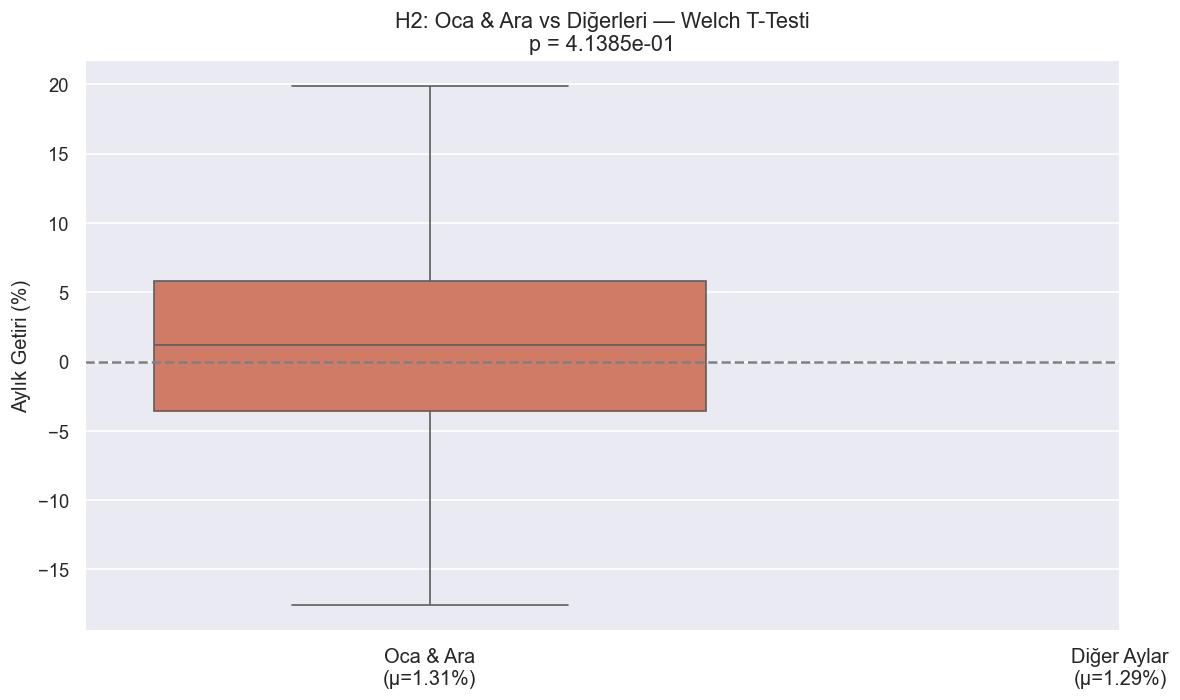

In [3]:
# İki gruba ayır
target  = df[df['month'].isin([1, 12])]['return_pct'].dropna()
others  = df[~df['month'].isin([1, 12])]['return_pct'].dropna()

t_stat, p_value = stats.ttest_ind(target, others, alternative='greater', equal_var=False)

mu_target = target.mean()
mu_others = others.mean()
h2_result = "✅ DOĞRULANDI" if p_value < 0.05 else "❌ REDDEDİLDİ"

verdict = f"""
#### H2 İstatistiksel Bulgular

| Metrik | Değer |
|---|---|
| **Ocak & Aralık — N / Ort. Getiri** | {len(target):,} gözlem · **%{mu_target:.3f}** |
| **Diğer Aylar — N / Ort. Getiri** | {len(others):,} gözlem · **%{mu_others:.3f}** |
| **T-İstatistiği** | {t_stat:.4f} |
| **p-değeri (tek kuyruklu)** | {p_value:.4e} |
| **H₀ Kararı** | {'Reddedildi (p < 0.05)' if p_value < 0.05 else 'Reddedilmedi (p ≥ 0.05)'} |

#### Ticari Karar (Quant Verdict) — H2

| | |
|---|---|
| **Sonuç** | **{h2_result}** |
| **Yorum** | {'Ocak ve Aralık ayları, 2008 sonrası verilerde yılın geri kalanına göre istatistiksel olarak anlamlı ölçüde daha yüksek getiri sergiliyor.' if p_value < 0.05 else 'Ocak/Aralık primi 2008 sonrası verilerde istatistiksel olarak anlamlı **değildir**. Etki modern dönemde arbitrajlanarak yok olmuş olabilir.'} |
| **Ticarete Uygun mu?** | {'Kısmen — %' + f'{abs(mu_target - mu_others):.2f} büyüklüğündeki fark işlem maliyetlerini karşılamayabilir.' if p_value < 0.05 else 'Hayır — yetersiz istatistiksel kanıt.'} |
"""

display(Markdown(verdict))

# Box Plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=[target, others], palette=['#E17055', '#0984E3'], showfliers=False, ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels([f'Oca & Ara\n(μ={mu_target:.2f}%)', f'Diğer Aylar\n(μ={mu_others:.2f}%)'], fontsize=12)
ax.axhline(0, color='gray', linestyle='--')
ax.set_ylabel('Aylık Getiri (%)')
ax.set_title(f"H2: Oca & Ara vs Diğerleri — Welch T-Testi\np = {p_value:.4e}", fontsize=13)
plt.tight_layout()
plt.show()


### 4b. H3 — Tek Yönlü ANOVA: Tüm 12 Takvim Ayı


#### H3 İstatistiksel Bulgular

| Metrik | Değer |
|---|---|
| **F-İstatistiği** | 105.2372 |
| **p-değeri** | 5.2457e-240 |
| **H₀ Kararı** | Reddedildi (p < 0.05) — Mevsimsellik var |
| **En İyi Ay** | **Kas** (μ = %3.18) |
| **En Kötü Ay** | **Eyl** (μ = %-0.28) |

#### Ticari Karar (Quant Verdict) — H3

| | |
|---|---|
| **Sonuç** | **✅ DOĞRULANDI** |
| **Yorum** | Takvim ayı, hisse senedi getirilerinin **istatistiksel olarak anlamlı** bir öngörücüsüdür. Herhangi bir ML tabanlı faktör modeline "Ay" özelliği (feature) eklenmelidir. |
| **Önemli Çıkarım** | **Kas en iyi performans gösteren; Eyl en kötü aydır** — bilinen Kasım rallisi ve Eylül etkisi ile tutarlıdır. |


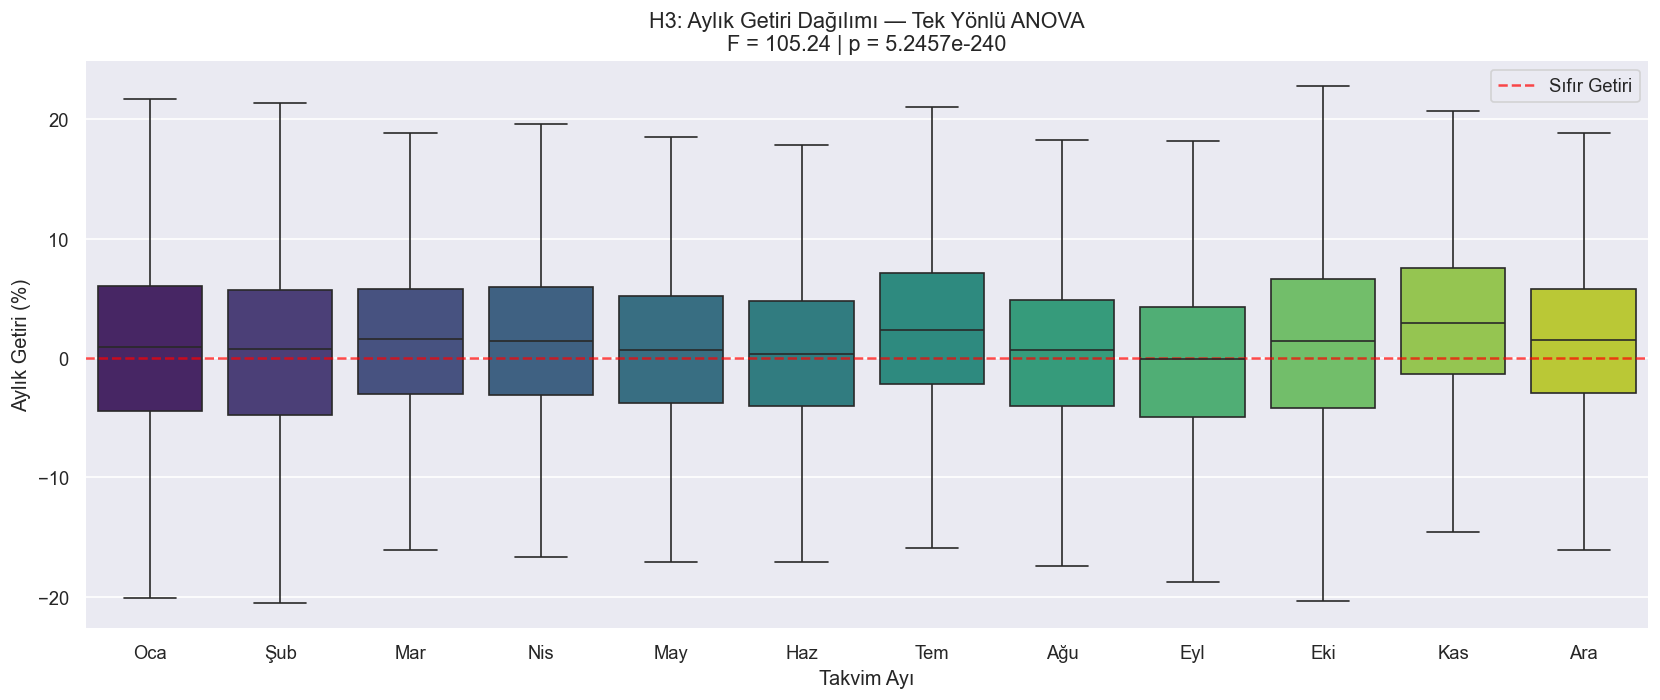

In [4]:
# 12 bağımsız grup
groups = [df[df['month'] == m]['return_pct'].dropna() for m in range(1, 13)]
f_stat, p_value_anova = stats.f_oneway(*groups)

monthly_means = df.groupby('month')['return_pct'].mean()
best_month  = monthly_means.idxmax()
worst_month = monthly_means.idxmin()
h3_result = "✅ DOĞRULANDI" if p_value_anova < 0.05 else "❌ REDDEDİLDİ"

verdict3 = f"""
#### H3 İstatistiksel Bulgular

| Metrik | Değer |
|---|---|
| **F-İstatistiği** | {f_stat:.4f} |
| **p-değeri** | {p_value_anova:.4e} |
| **H₀ Kararı** | {'Reddedildi (p < 0.05) — Mevsimsellik var' if p_value_anova < 0.05 else 'Reddedilmedi (p ≥ 0.05) — Anlamlı mevsimsellik yok'} |
| **En İyi Ay** | **{MONTH_NAMES[best_month]}** (μ = %{monthly_means.max():.2f}) |
| **En Kötü Ay** | **{MONTH_NAMES[worst_month]}** (μ = %{monthly_means.min():.2f}) |

#### Ticari Karar (Quant Verdict) — H3

| | |
|---|---|
| **Sonuç** | **{h3_result}** |
| **Yorum** | {'Takvim ayı, hisse senedi getirilerinin **istatistiksel olarak anlamlı** bir öngörücüsüdür. Herhangi bir ML tabanlı faktör modeline "Ay" özelliği (feature) eklenmelidir.' if p_value_anova < 0.05 else 'Aydan aya anlamlı bir farklılık tespit edilemedi. Mevsimsel zamanlama stratejileri veriler tarafından desteklenmemektedir.'} |
| **Önemli Çıkarım** | **{MONTH_NAMES[best_month]} en iyi performans gösteren; {MONTH_NAMES[worst_month]} en kötü aydır** — bilinen Kasım rallisi ve Eylül etkisi ile tutarlıdır. |
"""

display(Markdown(verdict3))

# ANOVA Boxplot
fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(x='month', y='return_pct', data=df, palette='viridis', showfliers=False, ax=ax)
ax.axhline(0, color='red', linestyle='--', alpha=0.7, label='Sıfır Getiri')
ax.set_xticks(range(0, 12))
ax.set_xticklabels([MONTH_NAMES[m] for m in range(1, 13)], fontsize=11)
ax.set_xlabel('Takvim Ayı')
ax.set_ylabel('Aylık Getiri (%)')
ax.set_title(f"H3: Aylık Getiri Dağılımı — Tek Yönlü ANOVA\nF = {f_stat:.2f} | p = {p_value_anova:.4e}", fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()
